In [1]:
from pathlib import Path
import json
from typing import cast
import testing
from run_types import CompRes


In [2]:
exps_dict_path = Path('./results/wlasl_satnac_16_only_improved.json')
print(exps_dict_path.exists())

True


In [3]:
split = 'asl100'

In [4]:
with open(exps_dict_path, 'r') as f:
    exps_dict = json.load(f)
asl100_exps = exps_dict[split]
print(len(asl100_exps))

8


In [5]:
runs_dir = Path('./runs') / split

In [6]:
summarised = {}
for model_name, exps in asl100_exps.items():
    expno = exps[0]
    print(f'{model_name} : {expno}')
    results_path = runs_dir / f'{model_name}_exp{expno}' / 'results' / 'best_val_loss.json'
    with open(results_path, 'r') as f:
        entry_res = cast(CompRes, json.load(f))
    

    res_key = "top_k_average_per_class_acc"

    summarised[model_name] = {
        'exp': expno,
        res_key : entry_res['test'][res_key]
    }

exps_summarised_dict_path = Path('./results/wlasl_satnac_16_only_improved_summarised.json')
with open(exps_summarised_dict_path, 'w') as f:
    json.dump({split: summarised}, f, indent=4)
    

    

R3D_18 : 006
R(2+1)D_18 : 007
S3D : 046
MViTv1_B : 003
MViTv2_S : 010
Swin3D_B : 003
Swin3D_S : 003
Swin3D_T : 003


In [7]:
import results

dict_keys(['asl100'])


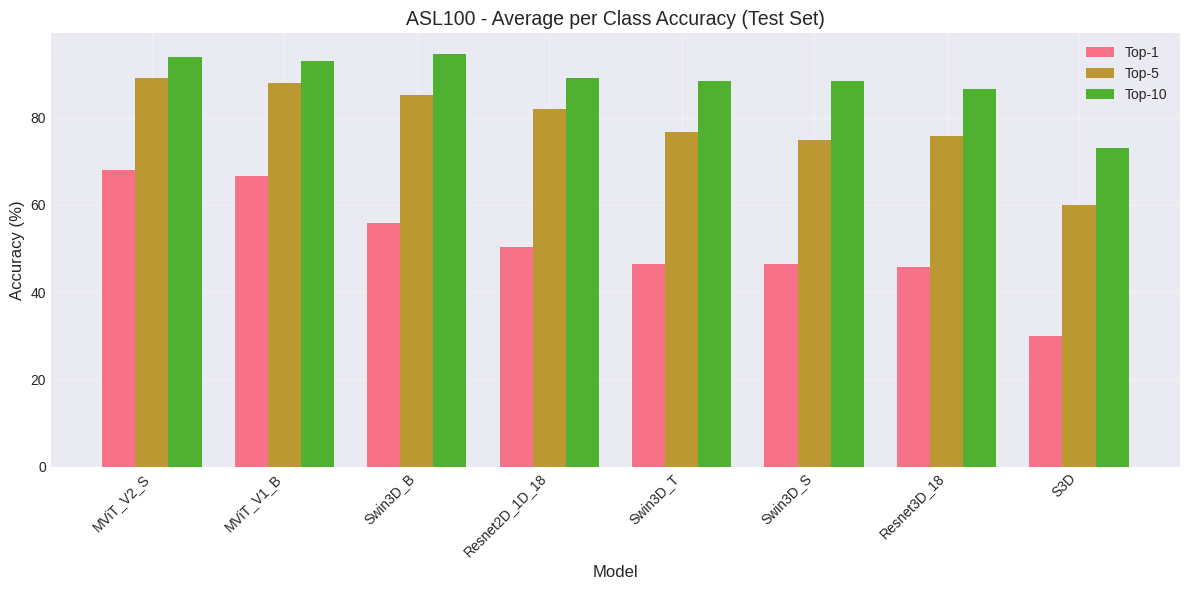

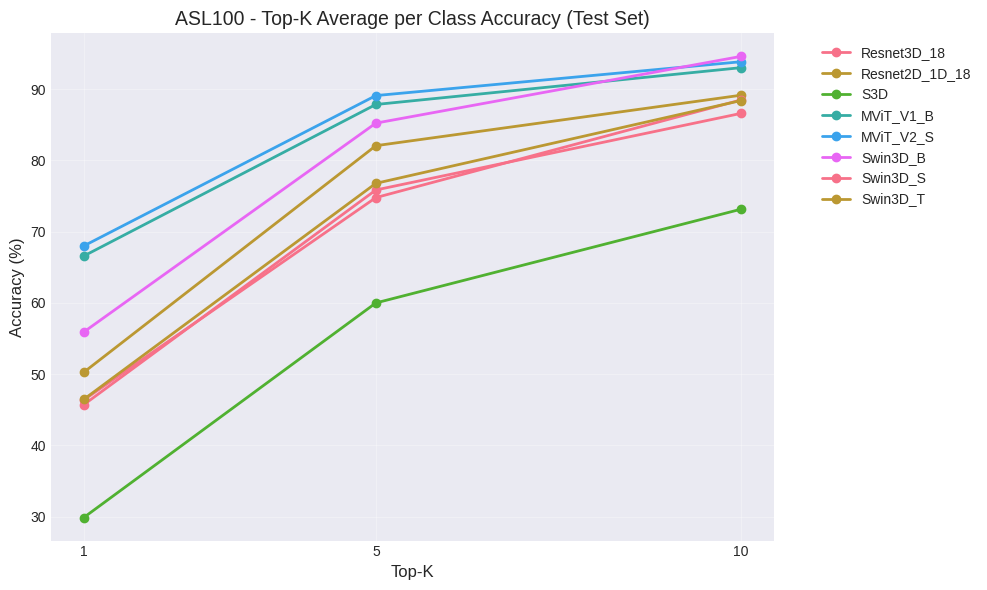

In [8]:
import visualise
df, results = visualise.run_visualizations('./results/wlasl_satnac_16_only_summary.json', extractor=visualise.extract_metrics_df_sumed, splits=[split])

In [ ]:
df, results = visualise.run_visualizations('./results/wlasl_satnac_16_only_improved_summarised.json', extractor=visualise.extract_metrics_df_sumed, splits=[split])